a = h/e = (3.99208e-15 ± 5.91926e-17) V s
b = (-0.42356 ± 0.03150) V
R^2 = 0.990089
========== Resultado para h/e ==========
m = (3.992077e-03 ± 5.919259e-05) V/THz
h/e experimental = (3.992077e-15 ± 5.919259e-17) V s
h/e aceptado     = 4.135668e-15 V s
Error porcentual = -3.47 %


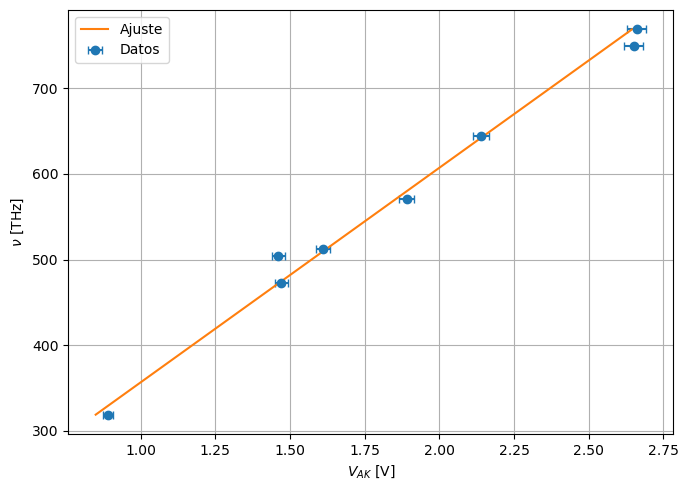

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# Cargar datos
# ============================================================

df = pd.read_csv("../datos/ccd_y_leds_limpio.csv")

V = df["V_AK_V"].to_numpy()
sigma_V = df["u_V_AK_V"].to_numpy()

nu_Hz = df["nu_Hz"].to_numpy()
nu_THz = nu_Hz / 1e12

# ============================================================
# Ajuste lineal
# Modelo físico:
#     V_AK = (h/e) nu + b
#
# Aunque la gráfica será nu contra V_AK, el ajuste se hace como
# V_AK contra nu porque la incertidumbre experimental está en V_AK.
# ============================================================

def modelo(nu_THz, a, b):
    return a * nu_THz + b

popt, pcov = curve_fit(
    modelo,
    nu_THz,
    V,
    sigma=sigma_V,
    absolute_sigma=True
)

a, b = popt
sigma_a, sigma_b = np.sqrt(np.diag(pcov))

# Como nu está en THz, a tiene unidades V/THz.
# Para obtener h/e en V s:
h_sobre_e = a * 1e-12
sigma_h_sobre_e = sigma_a * 1e-12

# ============================================================
# R^2 ponderado
# ============================================================

V_fit = modelo(nu_THz, a, b)

w = 1 / sigma_V**2
V_prom_pond = np.sum(w * V) / np.sum(w)

ss_res = np.sum(w * (V - V_fit)**2)
ss_tot = np.sum(w * (V - V_prom_pond)**2)

R2_pond = 1 - ss_res / ss_tot

# R^2 no ponderado, por si quieres reportarlo también
ss_res_np = np.sum((V - V_fit)**2)
ss_tot_np = np.sum((V - np.mean(V))**2)
R2 = 1 - ss_res_np / ss_tot_np 

# ============================================================
# Resultados
# ============================================================

print(f"a = h/e = ({h_sobre_e:.5e} ± {sigma_h_sobre_e:.5e}) V s")
print(f"b = ({b:.5f} ± {sigma_b:.5f}) V")
#print(f"R^2 ponderado = {R2_pond:.6f}")
print(f"R^2 = {R2:.6f}")

# ============================================================
# Cálculo de h/e a partir de la pendiente m
# ============================================================

# En este código se asume que el ajuste fue:
#     V_AK = m * nu_THz + b
#
# Entonces:
#     m tiene unidades V/THz
#     h/e = m * 1e-12  en V s

m = a
u_m = sigma_a

h_sobre_e_exp = m * 1e-12
u_h_sobre_e_exp = u_m * 1e-12

# Valor aceptado de h/e
h_sobre_e_teo = 4.135667696e-15  # V s

error_porcentual = (h_sobre_e_exp - h_sobre_e_teo) / h_sobre_e_teo * 100

print("========== Resultado para h/e ==========")
print(f"m = ({m:.6e} ± {u_m:.6e}) V/THz")
print(f"h/e experimental = ({h_sobre_e_exp:.6e} ± {u_h_sobre_e_exp:.6e}) V s")
print(f"h/e aceptado     = {h_sobre_e_teo:.6e} V s")
print(f"Error porcentual = {error_porcentual:.2f} %")

# ============================================================
# Gráfica: nu contra V_AK
# ============================================================

nu_grid = np.linspace(nu_THz.min(), nu_THz.max(), 300)
V_grid = modelo(nu_grid, a, b)

plt.figure(figsize=(7, 5))

plt.errorbar(
    V,
    nu_THz,
    xerr=sigma_V,
    fmt="o",
    capsize=3,
    label="Datos"
)

plt.plot(
    V_grid,
    nu_grid,
    label=(
        "Ajuste"
    )
)

plt.xlabel(r"$V_{AK}$ [V]")
plt.ylabel(r"$\nu$ [THz]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("graf_colores")
plt.show()